In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

In [55]:
data = pd.read_csv("data/generated_data.csv", delimiter=",", header=0)

data_dict = {
    "N": len(data),
    "x": data.X.values,
    "y": data.Y.values,
}

In [56]:
model = CmdStanModel(
    stan_file="models/regression_model.stan"
)

In [57]:
# just using the same parameters we used in class for now
# because they worked and I'm scared of changing them
fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=500, 
    iter_sampling=5000,
)

04:50:11 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/5500 [00:00<?, ?it/s, (Warmup)]

04:50:12 - cmdstanpy - INFO - CmdStan done processing.


In [58]:
fit.summary()

,Mean,MCSE,StdDev,5%,50%,95%,N_Eff,N_Eff/s,R_hat
lp__,-61.50930,0.013546,1.252530,-63.94760,-61.18770,-60.16600,8549.75,4734.08,0.999990
alpha,-11.59830,0.003335,0.356420,-12.18570,-11.59570,-11.00900,11424.70,6325.97,1.000290
beta,10.13050,0.003754,0.410948,9.45724,10.12540,10.80800,11983.80,6635.57,1.000440
sigma2,3.82199,0.007272,0.797408,2.71949,3.71850,5.27061,12025.50,6658.63,0.999869
sigma,1.94482,0.001801,0.199179,1.64909,1.92834,2.29578,12237.30,6775.93,0.999860


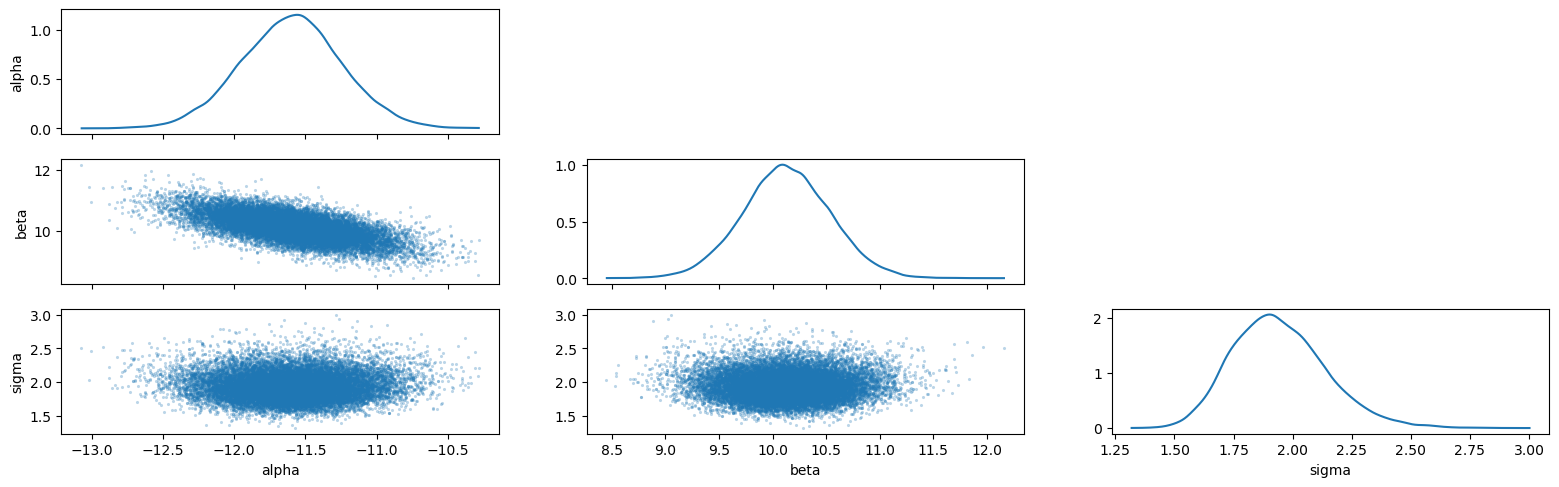

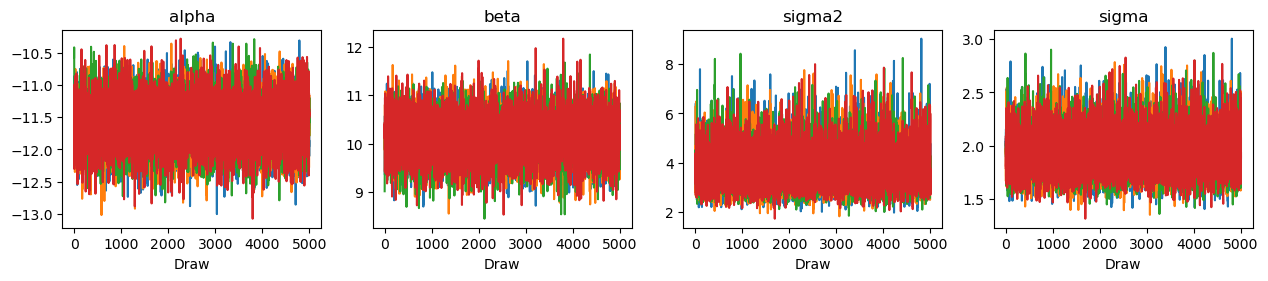

In [ ]:
idata = az.from_cmdstanpy(
    posterior=fit,
    observed_data={"y": data_dict["y"]}
)
idata
az.plot_pair(
    idata,var_names=["alpha","beta","sigma"],
    visuals={"scatter":{"alpha":0.3,"size":5}}
)
az.plot_trace(idata)

Median:
	alpha = -11.5958
	beta  =  10.1254
	sigma =  1.9283


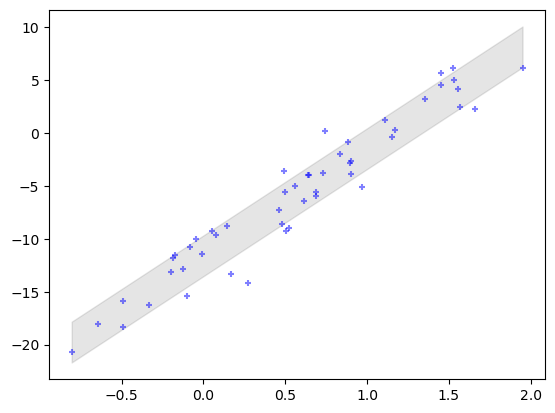

In [67]:
# N_posterior=len(idata.posterior["alpha"].flatten())
N_plot=100
pl_X=np.linspace(data_dict["x"].min(),data_dict["x"].max(),2)

alpha_med=np.median(idata.posterior["alpha"].data.flatten())
beta_med=np.median(idata.posterior["beta"].data.flatten())
sigma_med=np.median(idata.posterior["sigma"].data.flatten())
print(f"Median:\n\talpha = {alpha_med: .4f}\n\tbeta  = {beta_med: .4f}\n\tsigma =  {sigma_med:.4f}")

pl_Y_low=alpha_med+pl_X*beta_med-sigma_med
pl_Y_high=alpha_med+pl_X*beta_med+sigma_med

plt.fill_between(
    pl_X,
    pl_Y_low,
    pl_Y_high,
    color="k",
    alpha=0.1,
)
plt.scatter(data_dict["x"],data_dict["y"],marker="+",s=20,c="b",alpha=0.5)